   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64       1          66                      160                        83   
1   21       1          94                       98                        46   
2   55       1          64                      160                        77   
3   64       1          70                      120                        55   
4   55       1          64                      112                        65   

   Blood sugar  CK-MB  Troponin    Result  
0        160.0   1.80     0.012  negative  
1        296.0   6.75     1.060  positive  
2        270.0   1.99     0.003  negative  
3        270.0  13.87     0.122  positive  
4        300.0   1.08     0.003  negative  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       13

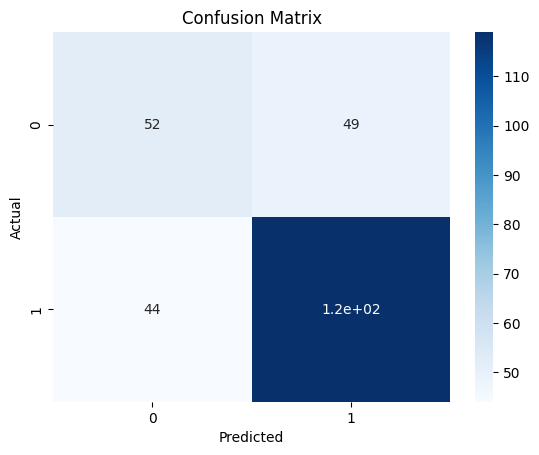

              precision    recall  f1-score   support

           0       0.54      0.51      0.53       101
           1       0.71      0.73      0.72       163

    accuracy                           0.65       264
   macro avg       0.62      0.62      0.62       264
weighted avg       0.64      0.65      0.65       264



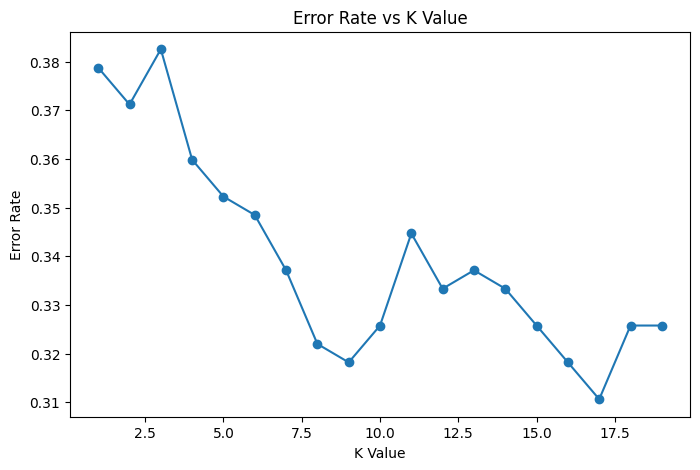

New Accuracy: 0.6628787878787878
Prediction: [0]
No Heart Disease (Negative)


In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Medicaldataset.csv")

# Display first rows
print(df.head())

# Display information
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Convert Result column into numeric values
df['Result'] = df['Result'].map({'negative':0, 'positive':1})

print(df.head())

# Split dataset into features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Import KNN model
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# Find best K value
error_rate = []

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plot Error Rate
plt.figure(figsize=(8,5))
plt.plot(range(1,20), error_rate, marker='o')
plt.title("Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

# Train model with better K value
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("New Accuracy:", accuracy_score(y_test, y_pred))

# Predict for new patient data
new_patient = pd.DataFrame(
    [[60,1,80,140,90,150,5.2,0.08]],
    columns=X.columns
)

# Scale the new patient data
new_patient_scaled = scaler.transform(new_patient)

# Prediction
prediction = knn.predict(new_patient_scaled)

print("Prediction:", prediction)

# Result message
if prediction[0] == 1:
    print("Heart Disease Detected (Positive)")
else:
    print("No Heart Disease (Negative)")